---
title: "Histograms"
subtitle: "DS 2023 | Communicating with Data"
---

<img src="https://virginia.box.com/shared/static/x5umwd3q5sq4tv7l6clcb5brip3sadmb.png" style="width:500px;"/>

## Overview

A histogram is a special case of a bar plot designed for visualizing the frequency statistics of a feature. 

It has the following properties:

- On the x axis, a numerical feature is converted into a category (in effect) by binning.
- The numeric bins are represented in ascending order.
- On the y axis is displayed the frequency of the observations for each bin.
- The bars are usually depicted contiguously, i.e. adjacent bars touch. Bar charts typically show separation between bars.

## Use cases

Histograms provide a quick way to inspect the centrality and dispersion of a distribution.

They allow you to inspect the shape of a distribution for modality, skew, and kurtosis.

They can also surface outliers and mutliple populations.

Histograms are frequently used to represent the distributions of measurements among a population, such as the height of people or the grades of students in a class. It shows how many cases have a certain measurement.

The ideal result of a histogram is a normal distribution, where values group around the mean.

> [!NOTE]
> 
> The term "histogram" was apparently invented by Karl Peason in 1891.
>
> Here is an example from his 1895 essay, "Contributions to the Mathematical Theory of Evolution":
> 
> <img src="https://virginia.box.com/shared/static/t0z8zfp6ec8un1ovj32uwwnse4hmowt5.png"/>
>
> [Source](https://www.jstor.org/stable/90649)

## Creating a histogram from scratch

Consider the following data set of yearly life expectancy rates and healthcare costs for a set of countries.

The two numeric features are good candidates for a histogram since they are ratio measures.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
healthexp = sns.load_dataset('healthexp')
healthexp = healthexp.set_index(['Year','Country'])
healthexp.sample(10)

Spending_USD  Life_Expectancy
Year Country                                     
1987 Canada             1357.453             76.7
1997 Japan              1529.586             80.5
1995 Canada             1984.944             78.0
1982 USA                1329.669             74.5
     Canada              996.086             75.6
     Great Britain       448.477             74.1
1980 Canada              791.812             75.2
1977 Germany             647.352             72.5
2002 Japan              2065.133             81.8
1988 Germany            1616.349             75.9

Let's focus on life expectancy, expressed as age, where we'd expect a gaussian distribution.

If we convert the continous numbers for age to discrete integers, we can treat age as a category to group on.

Getting value counts by age produces the following bar chart.

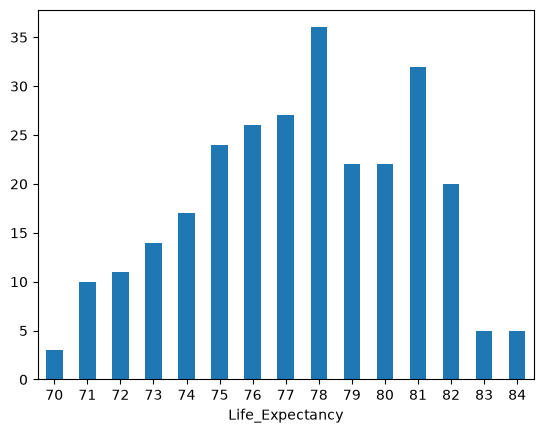

In [65]:
healthexp.Life_Expectancy.astype(int).value_counts().sort_index().plot.bar(rot=0)
plt.show()

Note that we have to sort the index since `.value_counts()` sorts by count and we need the age categories to be in sequential order.

Now, to meet the design requirements of a histogram, we can adjust the width of the bars to make them touch.

We do this by setting `width = 1`.

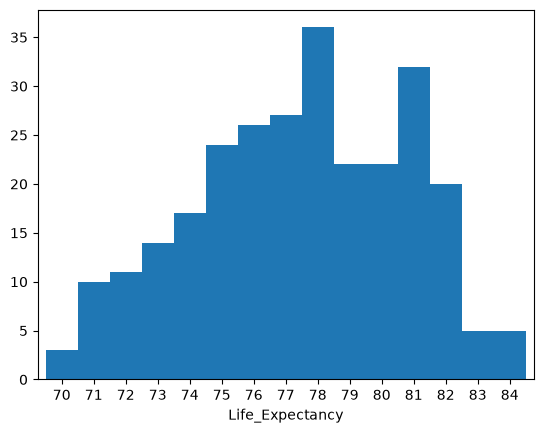

In [66]:
healthexp.Life_Expectancy.astype(int).value_counts().sort_index().plot.bar(width=1, rot=0)
plt.show()

In this example, we have created a bin for age value based on their integer value.

We might adjust this by grouping ages into groups of $5$ or $10$ years.

Or we could decide how many bins we want and use `pd.cut()` to create them, like so:

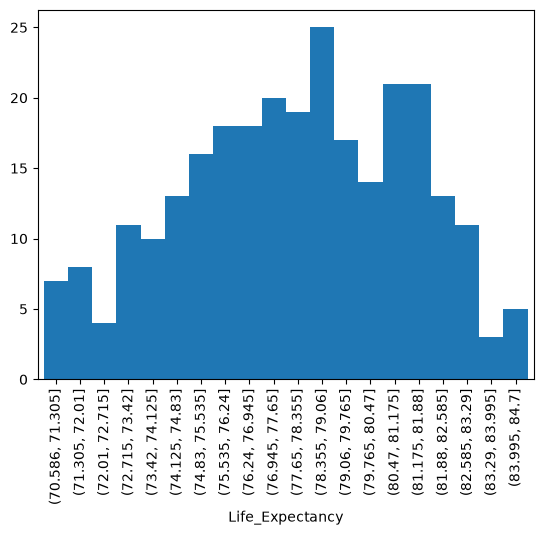

In [67]:
n_bins = 20
pd.cut(healthexp.Life_Expectancy, n_bins).value_counts().sort_index().plot.bar(width=1)
plt.show()

This is good, but the x axis is difficult to read. Also, it will change with each change of the parameter `n_bins`.

## Using Pandas' histogram function

So, we see how a histogram is constructed.

Panda's histogram method `.plot.hist()` does all this work for us and adds some nice formatting touches.

To use it, we give it a numeric feature and pass it the number of bins by which we want to group the observations. 

The default value is $10$.

Here we choose $20$ to mirror our bespoke version.

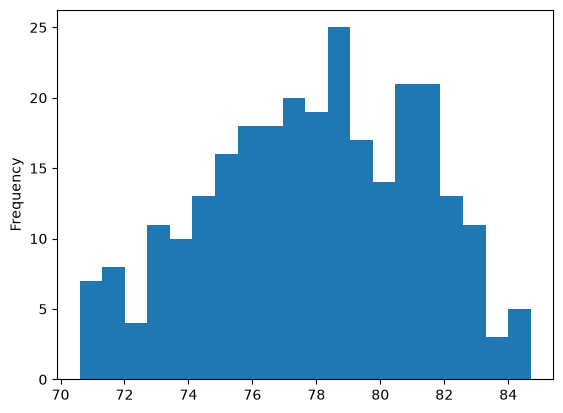

In [68]:
healthexp.Life_Expectancy.plot.hist(bins=n_bins)
plt.show()

It is common to represent the bars with borders, which we can accomplish as follows.

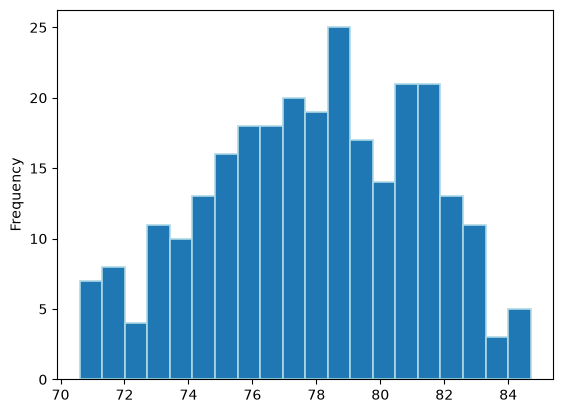

In [69]:
healthexp.Life_Expectancy.plot.hist(
    bins=n_bins, edgecolor='lightblue', linewidth=1.2)
plt.show()

Notice how the histogram function represents the x and y axes. 

The **x axis** is represented as a continuum, even though the bars themselves are discrete.

This allows the axis to remain true to the feature domain it represents, as well as to remain unchanged as the `bins` argument changes.

The **y axis** is now labeled "Frequency".

## Showing populations

As we might imagine, the distribution of life expectancy ages vary by country.

To visualize this, we can group the age variable by nation and show each histogram separately.

We can achieve this by creating a wide table in which `Country` is projected onto the column, and `Year` the row axis (or index), and the values come from `Life_Expectancy`.

In [73]:
life_exp_wide = healthexp['Life_Expectancy'].unstack()
life_exp_wide.head(10)

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,72.2,70.6,71.9,72.0,70.9
1971,72.8,NaN,70.8,71.9,72.9,71.2
1972,NaN,NaN,71.0,NaN,73.2,71.2
1973,NaN,NaN,71.3,NaN,73.4,71.4
1974,NaN,NaN,71.5,NaN,73.7,72.0
1975,NaN,73.0,71.4,NaN,74.3,72.7
1976,73.8,NaN,71.8,NaN,74.8,72.9
1977,NaN,NaN,72.5,NaN,75.3,73.3
1978,NaN,NaN,72.4,NaN,75.7,73.5


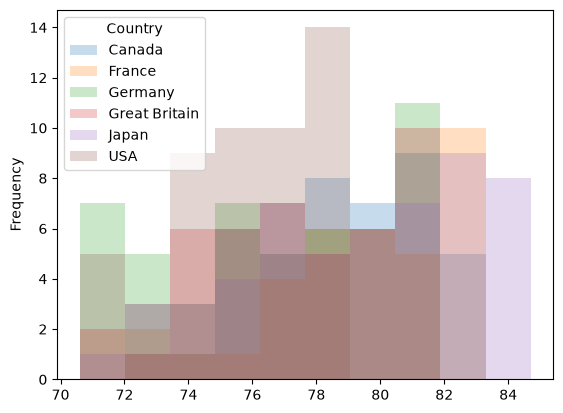

In [74]:
life_exp_wide.plot.hist(alpha=.25)
plt.show()

Here we can see that this histogram we created above masked the fact that the underlying data contained many populations.

To better visualize the differences, we can break these out using subplots as follows.

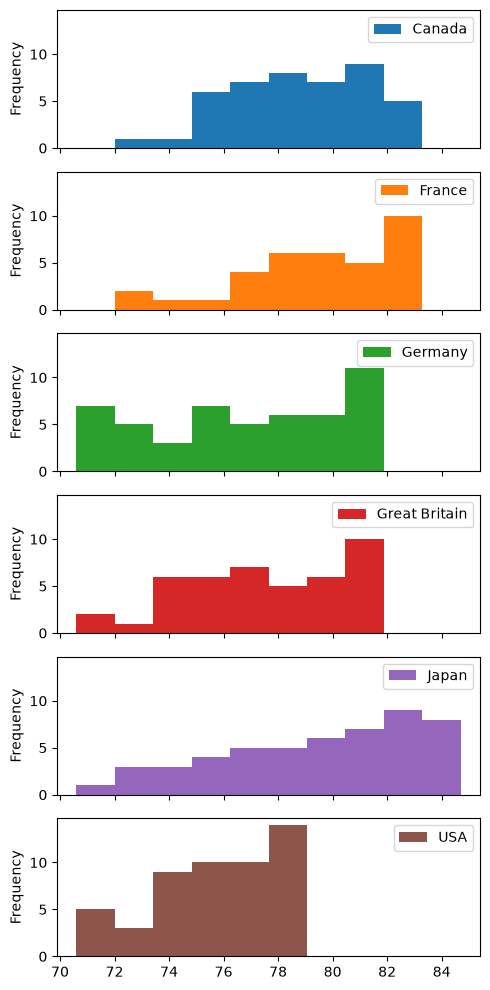

In [75]:
life_exp_wide.plot.hist(subplots=True, figsize=(5, 10), sharey=True)
plt.tight_layout()
plt.show()

## Histograms in exploratory data analysis

The histogram is often the first plot drawn of a new numeric measurement variable.

This is because summary statistics, like mean and standard deviation, don't tell use the whole story, as we learned from Anscombe's Quartet.

Here are tasks we use histograms for in exploratory data analysis to get a more complete understanding of a variable:

### Checking whether a summary statistic means anything

The mean of `Life_Expectancy` is $77.9$ and its median is $78.1$.

These figures are consistent with a roughly normal distribution, and a report that gave only those numbers would imply one.

But the subplots above show that the feature is a mixture of six populations. 

The value $77.9$ falls between them and describes none of them.

### Deciding whether to transform a feature

Skew is visible in a histogram immediately. 

`Spending_USD` has a skew of $1.30$, and a mean of $2789$ against a median of $2296$. 

The histogram shows the long right tail that accounts for the difference.

When you see all the data bunched up to the left of the right, you may want to rescale the data logaritmically.

This is similar to what we say with scatter plots and hexbin plots.

Here we get the log of the variable and then plot it. This opens up the bunched up data to better expose patterns.

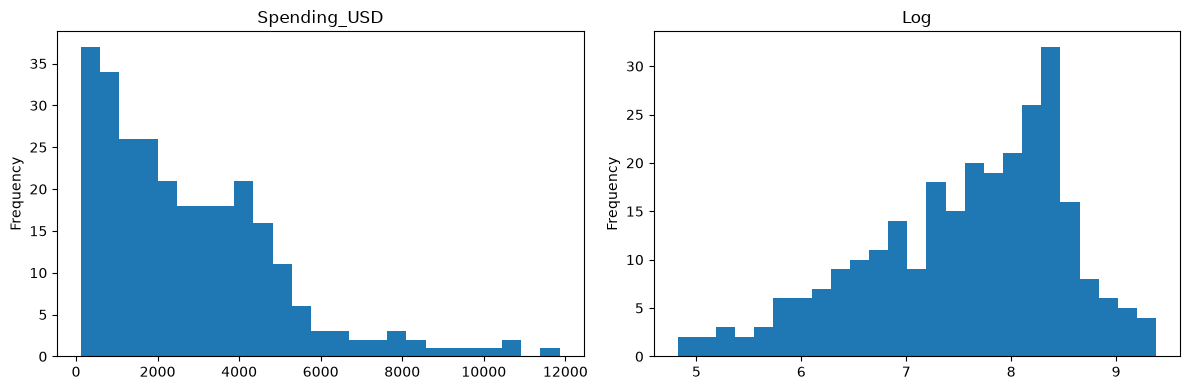

In [76]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
healthexp.Spending_USD.plot.hist(bins=25, ax=ax[0], title='Spending_USD')
healthexp.Spending_USD.apply(np.log).plot.hist(bins=25, ax=ax[1], title='Log')
plt.tight_layout()
plt.show()

### Assessing coverage and completeness

A histogram of a grouping variable, rather than of a measurement, reports how the dataset itself is populated.

We can use it to see if our data are balanced.

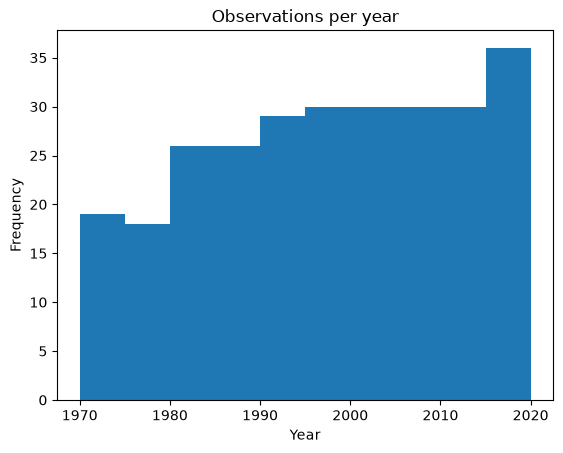

In [84]:
healthexp.reset_index().Year.plot.hist()
plt.title('Observations per year')
plt.xlabel('Year')
plt.show()

We can see that the bars rise through the 1970s and 1980s and level off in the mid 1990s.

This means that `healthexp` is unbalanced. 

On closer inspection of the data, we can see that of its $51$ years, $32$ have all six countries and five have only three. 

This is the same fact that produced the `NaN` values in the wide table above.

The consequence is that any statistic computed across all rows weights the later years more heavily, because more countries report in them.

### Detecting multiple populations

This is the task demonstrated in the previous section.

The pooled histogram of `Life_Expectancy` is unremarkable. Broken out by country, it resolves into six distributions with different locations and ranges.

The general task is to identify the grouping variable that accounts for the shape. When a pooled histogram is bimodal, or has a shoulder, or is wider than the measurement process would explain, a categorical feature usually accounts for it.

### Finding data quality problems

Several kinds of defect are visible in a histogram and invisible in the summary statistics:

- **Sentinel values.** A spike at $0$, $-1$, or $-999$ usually marks missing data that was never converted to `NaN`.
- **Heaping.** Spikes at multiples of $5$ or $10$ indicate rounding or self-reporting rather than measurement.
- **Censoring.** A pile-up in the first or last bin suggests the feature was capped, as with top-coded income.
- **Gaps.** An empty interval in the middle of a range suggests that a filter was applied upstream.

`healthexp` exhibits none of these, which is worth confirming rather than assuming.

## Choosing a bin value

In a histogram, the bin count is itself an exploratory parameter.

It determine the resolution of the plot.

Too few bins conceal structure, and too many resolve sampling noise into apparent features. 

One _under_ fits the data, the other _over_ fits it.

In other words, you have to play with it to find the most useful value.

This dependence on binning is one of the motivations for the density plot, which is the subject of the next lesson.